In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# The Coin Has No Memory, But You Do

*Against Your Gut: The Hidden Probability of Coin Streaks*

## Surprisingly Likely: The Mathematics of Streaks

There is a branch of mathematics I always found fascinating but hard to manipulate: counting methods, permutation and combination. I sincerely admire people able to compute probability on the spot just using counting methods also because you often find yourself amazed by the final result. And if you think that being able to calculate probability outcome on the spot is useless, well maybe Vegas is not your favourite place on Earth. For sure very expensive.   

In "How we know what isn't so: The fallibility of human reason in everyday life.", a remarkable 1991 book by [Thomas Gilovich](https://en.wikipedia.org/wiki/Thomas_Gilovich), there are several examples the author shows how the probability of events challenge our beliefs. Carl Sagan called it "a most illuminating book" that "shows how people systematically err in understanding numbers, in rejecting unpleasant evidence, in being influenced by the opinions of others. We're good in some things, but not in everything. Wisdom lies in understanding our limitations.".

"Rejecting unpleasant evidence" looks like a perfect topic a curious and inquisitive mind loves to get deep. 

In the book, Gilovich introduces the concept of the [Hot hand fallacy](https://en.wikipedia.org/wiki/Hot_hand) which is the tendency, for an athlete, to have streaks of success higher than their average performance. The story of the Hot Hand (phenomenon or fallacy?) has multiple, interesting angles but, in this notebook, I will concentrate on one of the reasons Gilovich uses to explain what is the psychological side leading us to blindly believe in the Hot hand concept in basketball. In the words of the author: 

>"*People expect sequences of coin flips, for example, to alternate between heads and tails more than they actually do. Because chance produces less alternation than our intuition leads us to expect, truly random sequences look too ordered or "lumpy." Streaks of 4, 5, or 6 heads in a row clash with our expectations about the behavior of a fair coin, although in a series of 20 tosses there is a 50-50 chance of getting 4 heads in a row, a 25 percent chance of five in a row, and a 10 percent chance of a streak of six. Because the average basketball player makes about 50% of his shots, he has a reasonably good chance of looking like he has the hot hand by making four, five, or even six shots in a row if he takes 20 shots in a game (as many players do).*"

I will make some further remarks at the end of the article about the current statistical analysis of the phenomenon, but it's true that most of the people would find very unusual streaks of 4, 5 or 6 heads in a row in a series of 20 tosses. I personally asked people if they would find awkward having 4 heads in a row in general, and the majority conceded it would not be impossible but extremely rare. For sure, a very small subset would go as far as not being surprised that actually the percentage of having 4 heads in a row in a series of 20 tosses is very close to 50%. The book does not give any demonstration this probability is true and we have no reason to doubt that Gilovich just made up this number. 

In the spirit of Reinventing the Wheel, I will take apart the claim, see how it works in its components and put it back to show that, in the end, the claim is true. In doing so, I will first show the mathematical background and, since we want to verify that math and reality match, I will perform several simulations of series of 20 tosses and see that almost half of them contains a series of 4 Heads in a row.

Talking about statistics, when I personally asked people if they would find awkward having 4 heads in a row in a series of tosses, the vast majority of them found me awkward. The only ones finding me normal were my closest friends.

## Heads in a Row, Counting and Probabilities 

The problem we want to solve is: what is the probability of getting 4 heads in a row in 20 tosses? This can be written as:

$$
P(\text{having four heads in a row}) = \frac{\text{number of times I have four heads in a row}}{\text{number of all possible combination of the tosses}}
$$


We will get there, but first let's build the method on a simpler case: consider the case 3 heads in a row across 5 tosses, where the numbers are small enough to check everything by hand.

Using H for heads and T for tails, a possible outcome of 5 tosses might be `THHTT` or `TTHHT`. How many possible outcomes are there in total? Math tells us that we can have $2^{5} = 32$ possible outcomes, small enough that we can write them all down:

In [2]:
from itertools import product

n = 5

sequences = ["".join(s) for s in product("HT", repeat=n)]

for i, seq in enumerate(sequences):
    print(f"{i+1:>2}. {seq}")

 1. HHHHH
 2. HHHHT
 3. HHHTH
 4. HHHTT
 5. HHTHH
 6. HHTHT
 7. HHTTH
 8. HHTTT
 9. HTHHH
10. HTHHT
11. HTHTH
12. HTHTT
13. HTTHH
14. HTTHT
15. HTTTH
16. HTTTT
17. THHHH
18. THHHT
19. THHTH
20. THHTT
21. THTHH
22. THTHT
23. THTTH
24. THTTT
25. TTHHH
26. TTHHT
27. TTHTH
28. TTHTT
29. TTTHH
30. TTTHT
31. TTTTH
32. TTTTT


Let's put the output in a table:

| `seq` | `seq` | `seq` | `seq` |
| --- | --- | --- | --- |
| `HHHHH` | `HHHHT` | `HHHTH` | `HHHTT` |
| `HHTHH` | `HHTHT` | `HHTTH` | `HHTTT` |
| `HTHHH` | `HTHHT` | `HTHTH` | `HTHTT` |
| `HTTHH` | `HTTHT` | `HTTTH` | `HTTTT` |
| `THHHH` | `THHHT` | `THHTH` | `THHTT` |
| `THTHH` | `THTHT` | `THTTH` | `THTTT` |
| `TTHHH` | `TTHHT` | `TTHTH` | `TTHTT` |
| `TTTHH` | `TTTHT` | `TTTTH` | `TTTTT` |

We have 32 possible combinations. How many of them contains at least 3 heads in a row? 

In [3]:
streak = 3
target = "H" * streak

matching = [seq for seq in sequences if target in seq]

print(f"Sequences containing at least {streak} heads in a row: {len(matching)} out of {len(sequences)}\n")
for i, seq in enumerate(matching):
    print(f"{i+1:>2}. {seq}")

Sequences containing at least 3 heads in a row: 8 out of 32

 1. HHHHH
 2. HHHHT
 3. HHHTH
 4. HHHTT
 5. HTHHH
 6. THHHH
 7. THHHT
 8. TTHHH


Updating the table to highlight sequences containing at least 3 consecutive heads: 

| `seq` | `seq` | `seq` | `seq` |
| --- | --- | --- | --- |
| `HHHHH` | `HHHHT` | `HHHTH` | `HHHTT` |
| ~~`HHTHH`~~ | ~~`HHTHT`~~ | ~~`HHTTH`~~ | ~~`HHTTT`~~ |
| `HTHHH` | ~~`HTHHT`~~ | ~~`HTHTH`~~ | ~~`HTHTT`~~ |
| ~~`HTTHH`~~ | ~~`HTTHT`~~ | ~~`HTTTH`~~ | ~~`HTTTT`~~ |
| `THHHH` | `THHHT` | ~~`THHTH`~~ | ~~`THHTT`~~ |
| ~~`THTHH`~~ | ~~`THTHT`~~ | ~~`THTTH`~~ | ~~`THTTT`~~ |
| `TTHHH` | ~~`TTHHT`~~ | ~~`TTHTH`~~ | ~~`TTHTT`~~ |
| ~~`TTTHH`~~ | ~~`TTTHT`~~ | ~~`TTTTH`~~ | ~~`TTTTT`~~ |

We have 8 sequences with at least 3 consecutive Heads out of 32 and the resulting probability is:

$$
P(\text{3 heads in a row}) = \frac{\text{number of times 3 heads in a row}}{\text{number of all possible combination of a sequence of 5 tosses}} = \frac{8}{32} = 0.25
$$

At the end, the probability is $25\%$, or one out of four. Is it the number you would have expected? The idea one has in mind of what is likely or unlikely is very often subjective, but if you flip a coin 5 times and you get three Heads in a row I am sure you would consider something worth noticing. By the way, the probability of having three heads in a row in a sequence of five tosses, it's different from the probability to have three heads in a row *at the start of the sequence*. I think this difference is not immediate in our mind and is a "surprise factor" we tend to underestimate. We notice streaks when they start appearing and forget what happened right before and this, possibly, leverages our surprise when we start noticing a phenomenon (the probability to start a sequence with at least 3 heads in a row is 4 out of 32 or $12.5\%$, the half of the probability we just calculated).

With small numbers is easier to compute the probability by listing all possible outcomes, but when the numbers start growing, we need to find mathematical way to compute the probability. In a scenario where we want to consider a series of 20 tosses, all the possible outcomes are more than one million and I don't think I have enough space in my notebook to list them all. 

Notice what we just did: rather than counting the sequences with the streak, we identified the ones without it and subtracted. That move has a name and we will see how to apply it in the next sections.

## Computing the probability in the general case. Or the superpower I wish I had.

How can we compute the probability of the event we are discussing without resorting to manually counting all occurrences? That's the kind of superpower I wish to have: to be able to quickly be able to compute chances with so called counting methods. More than a superpower, it might just be the right combination of learning the right methods and time to devote to learn the skill. But at least, if you have the willingness to learn, you can understand how to do it and derive a mathematical formula to compute this probability. 

To make things easy, let's derive the formula for the case of 5 flips and we will then use the general case when we will turn to 20 flips. 

### Introducing the complement rule

The complement rule is the way to go when computing the number of an event **not** occurring is easier than computing the number of an event occurring. The rule follows from something very simple: any event either happens or it does not, and one of the two must be true. This means $P(E) + P(\neg E) = 1$, which gives us $P(E) = 1 - P(\neg E)$. If computing $P(\neg E)$ is easier than computing $P(E)$ directly, we use the latter to obtain the former.

In the case of calculating the number of times we have 3 heads in a row in a series of 5 flips, the idea is that rather than counting sequences with 3 heads in a row (messy), count those without, then subtract:

$$
P(\text{at least 3 in a row}) =  1 - P(\text{no run with 3 or more Heads}) 
$$

We can think in a recursive way: let $f(n)$ be the number of valid sequence of length $n$ with no run of 3 or more Heads. To make more intuitive what $f(n)$ is, let's consider our simpler case with $n=5$. To stress it more, we consider a valid sequence a sequence in which we don't have 3 or more consecutive heads, like `HHTHH` or `THHTH`. 

*$f(0)$ is the number of valid sequence of length $0$ with no run of 3 or more Heads.* 

$f(0) = 1$ by convention. It's not very intuitive, I know, but you can see it as if you don't toss the coin, it's the empty sequence and so there's nothing in it, and nothing can violate the rule. 

*$f(1)$ is the number of valid sequence of length $1$ with no run of 3 or more Heads.*

If we flip a coin once, we obtain two possible results: `H` or `T`. Both are valid sequences, meaning that they do not contain three or more Heads. So we can conclude $f(1) = 2$ 

*$f(2)$ is the number of valid sequence of length $2$ with no run of 3 or more Heads.*

We flip the coin twice, we can have four possible results: `HH`, `TT`, `HT`, `TH`. All four results form a valid sequence as they do not have three or more Heads. We conclude: $f(2) = 4$

*$f(3)$ is the number of valid sequence of length $3$ with no run of 3 or more Heads.*

What about flipping the coin three times in a row? Well, in this case all sequences are valid except one: `HHH`. The latter is not a valid sequence, while all the remaining 7 are (the ones like `TTT`, `HTH`, `TTH` and so on). We conclude $f(3) = 7$

Notice that for $n < 3$ you can't even fit a run of 3, so all $2^n$ sequences are valid. At $n=3$ you subtract exactly 1 (the `HHH` sequence).

You can build all cases in a recursive way. The key observation is that every valid sequence must contain at least one T: a sequence ending in an unbroken run of 3 or more heads is, by definition, not valid. So we can ask: where does the last T appear? It can only be in one of three positions relative to the end of the sequence, and each case pins down exactly how many heads come after it. These are the only three cases, we cannot add a fourth one like $\dots, H, H, H, T$: if three heads appear before the last tail, the sequence already contains a run of three consecutive heads and is therefore not valid. Any valid sequence must end with one of these cases:

- $\dots, T$ and all the preceding $n-1$ flips are valid. We call them $f(n-1)$
- $\dots, H,T$ and all the preceding $n-2$ flips are valid. We call them $f(n-2)$
- $\dots, H, H, T$ and all the preceding $n-3$ flips are valid. We call them $f(n-3)$

We can now write the general formula in the case of ***three consecutive*** heads:

$$
f(n) = f(n-1) + f(n-2) + f(n-3) 
$$

Using recursion to compute a function is one of the funniest, surprising and exhilarating things you can do in math. OK, that's maybe a bit of a stretch, it's more a personal statement. Let's plug our numbers in and:  


$$
f(5) = f(5-1) + f(5-2) + f(5-3) = f(4) + f(3) + f(2) = f(4) + 7 + 4 = f(4) + 11
$$

We already calculated $f(3) = 7$ and $f(2) = 4$. What about $f(4)$? Using the very same formula, we can calculate $f(4)$ being $f(4) = f(3) + f(2) + f(1) = 7 + 4 + 2 = 13$. So, finally, we have $f(5) = 13 + 11 = 24$, meaning we have 24 possible outcomes that do not contain three or more Heads in a row. At the same time, for the complementary rule, this means we have $32-24=8$ outcomes with three or more Heads in a row. And the result we get using recursion is the same we obtained by manually listing all the possible cases.

### The general Case, finally

Using the same reasoning, we can compute the number of valid sequences if we want to consider 4 Heads in a row in a series of 20 tosses. In this case, the valid sequences are defined as:

- $\dots, T$ and all the preceding $n-1$ flips are valid. We call them $f(n-1)$
- $\dots, H,T$ and all the preceding $n-2$ flips are valid. We call them $f(n-2)$
- $\dots, H, H, T$ and all the preceding $n-3$ flips are valid. We call them $f(n-3)$
- $\dots, H, H, H, T$ and all the preceding $n-4$ flips are valid. We call them $f(n-4)$

What we have done, is to also add a new possible sequence, $f(n-4)$, as we allow, in the general case, sequences with three consecutive Heads (but not with 4 or more). In this case, the recursive formula is:

$$
f(n) = f(n-1) + f(n-2) + f(n-3) + f(n-4)
$$

The base cases are now $f(0)=1$, $f(1)=2$, $f(2)=4$, $f(3)=8$ (all sequences of length $\leq 3$ are valid), and $f(4)=15$ (all 16 minus `HHHH`). Notice how the base cases change too, not only the formula: since we now allow runs of up to three heads, `HHH` is a valid sequence and $f(3) = 8$.

What we need to compute is $f(20)$, the sequence of 20 valid consecutive tosses:

$$
f(20) = f(19) + f(18) + f(17) + f(16)
$$

Each term calculated using the same recursive formula. Now, we can spend our week computing this number by hand or implementing a python cell doing the job for us. The choice is up to us and it's very clear: the following is the python cell.

In [4]:
def f(n):
    base_cases = {0: 1, 1: 2, 2: 4, 3: 8, 4: 15}
    if n in base_cases:
        return base_cases[n]
    
    memo = dict(base_cases)
    for i in range(5, n + 1):
        memo[i] = memo[i-1] + memo[i-2] + memo[i-3] + memo[i-4]
    return memo[n]

n_tosses = 20
valid = f(n_tosses)
total = 2 ** n_tosses

print(f"Valid sequences (no 4 heads in a row): {valid}")
print(f"Total sequences:                       {total}")
print(f"P(at least 4 heads in a row):          {1 - valid/total:.4f}")


Valid sequences (no 4 heads in a row): 547337
Total sequences:                       1048576
P(at least 4 heads in a row):          0.4780


So, from a theoretical point of view, the probability to obtain at least 4 heads in a row is approximately $47.8 \%$. In his book, Gilovich rounded it further to 50-50 but we can definitely agree with him.

## From theory to practice: Let's flip again

Have you ever heard someone saying "I don't care about numbers. I am a practical guy"? It happened to me and I think it's a feeling you can understand especially if people are not used to mathematical demonstrations and proofs. If you look back at the demonstration I gave in the previous sections, and if you are not familiar with concepts like recursion or building functions, it's easy you need to read it more than once to understand it. I will not lie and say that I came up with it all by myself: I checked books and online articles to verify it works and used Claude to double check I was doing the right passages. How can we be sure that the probability we arrived at with the mathematical formula is correct? One possible way to verify it, is to do it. Flip a coin 20 times in a row and record the results; we then flag all outputs containing 4 or more Heads in a row and calculate the ratio between that number and the total number of trials. That's the kind of task you can perform if you find yourself in a situation where you have nothing better to do, like you're in prison, or stuck in a working meeting you couldn't care less about, or watching the latest Marvel movie. I found all three scenarios more or less equivalent. Or, we can simulate with python the toss of the coins and record results. It's up to you. In this notebook, I will go on with python.

The next cell simulates the flipping of 20 coins with a given number of trials and computes the ratio, i.e. the probability, of the number of sequences with our constraint divided by the total number of trials, to see if the simulation results match the expected result obtained theoretically.

Trials:                    10000
Trials with streak of 4+: 4718
Proportion:                0.4718
Theory:                    0.478


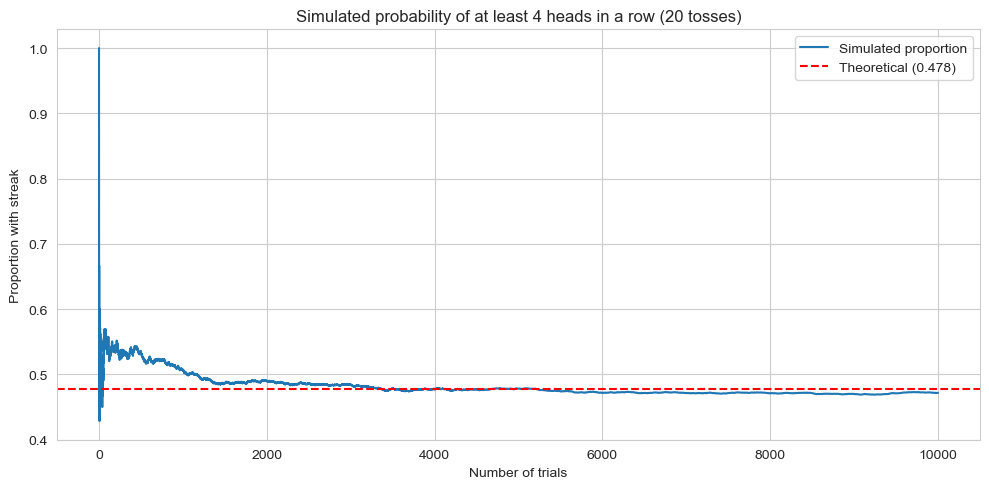

In [5]:
def flip_coins(n_tosses, seed):
    rng = np.random.default_rng(seed)
    return ["H" if x == 1 else "T" for x in rng.integers(0, 2, size=n_tosses)]

def has_streak(sequence, streak=4):
    count = 0
    for coin in sequence:
        if coin == "H":
            count += 1
            if count >= streak:
                return True
        else:
            count = 0
    return False

# --- parameters ---
n_trials = 10_000
streak   = 4
n_tosses = 20
theory   = 0.4780
# ------------------

results = []
for trial in range(n_trials):
    sequence = flip_coins(n_tosses=n_tosses, seed=trial)
    results.append(has_streak(sequence, streak=streak))

# cumulative proportion after each trial
cumulative = np.cumsum(results) / np.arange(1, n_trials + 1)

print(f"Trials:                    {n_trials}")
print(f"Trials with streak of {streak}+: {sum(results)}")
print(f"Proportion:                {sum(results)/n_trials:.4f}")
print(f"Theory:                    {theory}")

# plot
fig, ax = plt.subplots(figsize=(10, 5))

sns.lineplot(x=range(1, n_trials + 1), y=cumulative, ax=ax, label="Simulated proportion")
ax.axhline(theory, color="red", linestyle="--", label=f"Theoretical ({theory})")

ax.set_xlabel("Number of trials")
ax.set_ylabel("Proportion with streak")
ax.set_title(f"Simulated probability of at least {streak} heads in a row ({n_tosses} tosses)")
ax.legend()

plt.tight_layout()
plt.show()


The graph shows that simulations confirm the theoretical value. With fewer trials, the estimate is noisier: it can land well above or below the theoretical value. As the number of trials grows, the simulation stabilises around 0.4780, which is exactly what we expect from the law of large numbers. So reality matches theory, and this is not a surprise.

Without repeating the full derivation, let's also simulate the cases for 5 and 6 or more consecutive Heads, just to confirm the pattern holds. 

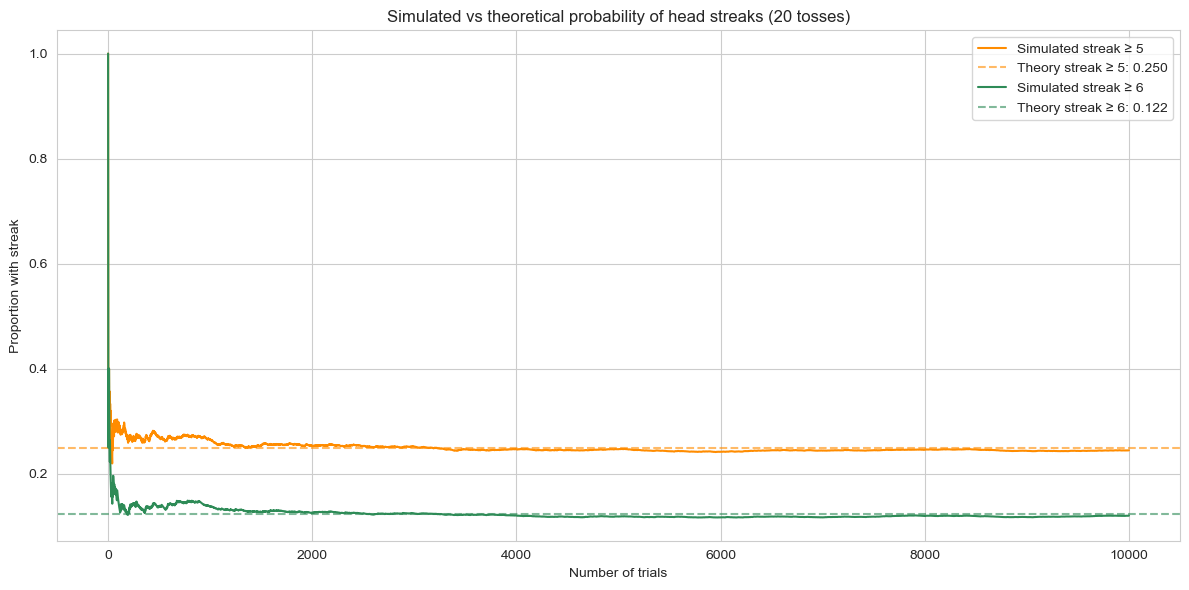

In [6]:
def theoretical_probability(n_tosses, streak):
    base_cases = {i: 2**i for i in range(streak)}
    base_cases[streak] = 2**streak - 1
    
    memo = dict(base_cases)
    for i in range(streak + 1, n_tosses + 1):
        memo[i] = sum(memo[i - j] for j in range(1, streak + 1))
    
    return 1 - memo[n_tosses] / 2**n_tosses


def simulate_streaks(n_tosses, streak, n_trials):
    results = []
    for trial in range(n_trials):
        sequence = flip_coins(n_tosses=n_tosses, seed=trial)
        results.append(has_streak(sequence, streak=streak))
    return np.cumsum(results) / np.arange(1, n_trials + 1)


# --- parameters ---
n_trials = 10_000
n_tosses = 20
streaks  = [5, 6]
# ------------------

fig, ax = plt.subplots(figsize=(12, 6))

colors = ["darkorange", "seagreen"]

for streak, color in zip(streaks, colors):
    theory = theoretical_probability(n_tosses, streak)
    cumulative = simulate_streaks(n_tosses, streak, n_trials)
    
    sns.lineplot(x=range(1, n_trials + 1), y=cumulative,
                 ax=ax, color=color, label=f"Simulated streak ≥ {streak}")
    ax.axhline(theory, color=color, linestyle="--", alpha=0.6,
               label=f"Theory streak ≥ {streak}: {theory:.3f}")

ax.set_xlabel("Number of trials")
ax.set_ylabel("Proportion with streak")
ax.set_title(f"Simulated vs theoretical probability of head streaks ({n_tosses} tosses)")
ax.legend()

plt.tight_layout()
plt.show()


Again, simulation and theoretical values lead to the same results. And having a $25\%$ chance of getting 5 Heads in a row when flipping a coin 20 times is quite remarkable, if you ask me.

## Conclusion: Are you surprised?

[The original paper about the hot hand fallacy](https://www.sciencedirect.com/science/article/abs/pii/0010028585900106) was published in 1985 and met with scepticism from the start, particularly from people working in basketball. Recent studies have shown that a very small effect may exist, in the order of a few percentage points. This does not change the central point of this article.

From a probabilistic standpoint, there is a consistent gap between what we expect to see and what actually happens. As we showed both mathematically and through simulation, streaks are far more common than our intuition suggests. We notice them, we remember them, and we treat them as meaningful. The coin, as the title says, has no memory. We do.

That gap between intuition and reality is also one of the reasons it is so hard to beat a casino or a bookmaker. They know the actual probabilities. Quite often, we do not. But that is a story for another article.